# PIPELINE FAST TUNING TEST — saute le benchmark MLlib (RF/LogReg/DecisionTree/NaiveBayes), va direct sur XGBoost

Consomme la sortie de `EDA_final.ipynb` (`PATH_TRAIN_OUT` / `PATH_SCORER_OUT` — parquet nettoyé,
catégorielles encore brutes). Encode, assemble, entraîne, évalue, sauvegarde, puis score.

**Principe de non-fuite** : tout ce qui est appris (indexeurs, encodeurs, poids de classe, modèle)
est **fit uniquement sur le train**, sauvegardé en `PipelineModel`, puis **rechargé tel quel** pour
scorer `dataset_a_scorer` — même logique que l'`Imputer`/les bornes IQR/les flags dans la Partie 1
EDA.

**Corrections apportées dans cette version (vs. V1) :**
- Ajout du **nettoyage de frontière par Tomek Links** (guide section 7.6bis), en pandas, sur le
  train étiqueté uniquement, **avant** le split train/validation.
- Ajout de la **pondération inverse-fréquence par classe** (guide section 7.6), recalculée
  **après** Tomek Links (la distribution des classes change), injectée via `weightCol` dans le
  classifieur.
- Correction d'une affirmation fausse en section 10 (V1) : `RandomForestClassifier` **supporte**
  `weightCol` depuis Spark 3.0 — le guide (section 7.5) l'utilise explicitement. La V1 prétendait
  le contraire, ce qui n'était pas cohérent avec le guide.
- Le lookup manuel `F.udf(...)` en section scoring remplacé par `IndexToString` (guide section
  7.3), qui est l'outil MLlib documenté pour cette conversion indice → nom de produit.

**Plan :**
1. Imports & configuration
2. Chargement du train nettoyé
3. Nettoyage de frontière (Tomek Links)
4. Split train / validation
5. Pondération inverse-fréquence par classe
6. Construction du pipeline (encodage → assemblage → modèle pondéré)
7. Entraînement
8. Évaluation (accuracy, F1 pondéré, matrice de confusion)
9. Importance des variables
10. Refit sur 100% du train (poids recalculés) & sauvegarde
11. Scoring (`dataset_a_scorer`)
12. Limites de cette V1.1 & prochaines étapes

## 1. Imports & configuration

In [1]:
!pip install seaborn
!pip install imblearn

In [2]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CORRECTIF (guide section 7.6bis) : Tomek Links ne s'applique qu'a dataset_produit
# (~140K lignes, sous-ensemble eligible, modele multi-classes) -- jamais a
# dataset_eligibilite (3M+ lignes, population complete, modele binaire traite ici).
# L'appliquer ici faisait planter le driver (OOM sur .toPandas() de 3M lignes,
# TomekLinks n'etant pas distribue). Import retire ; a reutiliser tel quel dans le
# futur notebook dataset_produit (section 6.4ter du guide), pas ici.
# from imblearn.under_sampling import TomekLinks


In [3]:
# ═══ Bascule LOCAL / MinIO ═══
LOCAL_MODE = False  # <-- bucket MinIO complet (33 parquet)

if LOCAL_MODE:
    # Test sur un seul fichier téléchargé localement
    PATH_TRAIN_IN = "part-00000.parquet"
    PATH_TRAIN_OUT = "new_test/part-00000_final.parquet"
    PATH_SCORER_IN = None   # pas encore testé en local
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "./models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "./models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"
    FLAGS_A_DROPPER_PATH = "./models/flags_extreme_a_dropper.json"
else:
    # Cluster / MinIO (bucket complet)
    # CORRECTIF : bucket "processed-data" ne contient que deux dossiers reels --
    # dataset_eligibilite/ (ce qu'on traite ici) et dataset_produits/ (hors perimetre
    # pour l'instant, prediction d'eligibilite uniquement). Les anciens chemins
    # dataset_train_produits/ et dataset_a_scorer/ n'existent pas dans ce bucket.
    PATH_TRAIN_IN = "s3a://processed-data/dataset_eligibilite/"
    PATH_TRAIN_OUT = "s3a://processed-data/dataset_eligibilite_final/"
    # Pas encore de dataset a scorer separe pour l'eligibilite -- laisse a None
    # (meme convention que la branche LOCAL_MODE=True) jusqu'a ce qu'il existe sur MinIO.
    PATH_SCORER_IN = None
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "s3a://ml-scoring/models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "s3a://ml-scoring/models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "s3a://ml-scoring/models/outlier_bounds/"
    FLAGS_A_DROPPER_PATH = "s3a://ml-scoring/models/flags_extreme_a_dropper/"

In [4]:
# CORRECTIF POTENTIEL : ces deux listes DOIVENT rester identiques a celles de la
# Partie 1 EDA (section 0) -- si l'une evolue sans l'autre, le pipeline plante au
# fit (colonne absente) ou encode silencieusement moins de colonnes que prevu.
# TODO V2 : factoriser dans un module partage (ex. config.py) importe par les deux
# notebooks, plutot que duplique ici.
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS", "BPR",
]
# CORRECTIF : BPR est un code numerique (int64, 12 modalites : 1, 17, 27, 30,
# 43, 45, 50, 57, 64, 78, 81, 90) sans relation d'ordre -- ce n'est PAS une
# quantite. Laisse tel quel, il finissait dans colonnes_features_numeriques()
# (section 6/7) comme feature numerique brute : le modele apprenait un ordre
# arbitraire entre les codes (78 > 45) qui n'a aucun sens metier. Basse
# cardinalite (12) -> sa place est ici, StringIndexer + OneHotEncoder
# (section 6) plutot qu'assemble tel quel comme numerique. Meme logique a
# appliquer a toute future colonne "code" numerique a faible cardinalite --
# ne pas se fier au dtype pandas/Spark, se fier au nombre de modalites.
COL_HAUTE_CARDINALITE = "CODE_VILLE"  # indexe seul, jamais one-hot (haute cardinalite -- nb exact calcule dynamiquement section 6, cf. nb_modalites_ville)
COL_LABEL = "label_eligibilite"
COLS_A_EXCLURE_DES_FEATURES = ["label_code", "label_eligibilite"]  # cible, sous ses deux formes

# CORRECTIF (variables utilisees plus loin dans le notebook -- section 4, 6, 9bis,
# 9quater, 10 -- mais jamais definies : NameError garanti a l'execution sans ca) :
RANDOM_SEED = 42
MODEL_PATH = "s3a://ml-scoring/models/pipeline_eligibilite_v1"
PATH_PREDICTIONS_OUT = "s3a://processed-data/predictions_eligibilite/"


## 2. Spark session & chargement du train nettoyé

In [5]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F


def get_spark() -> SparkSession:
    if LOCAL_MODE:
        builder = (
            SparkSession.builder
            .master("local[*]")
            .appName("training_pipeline_scoring")
            .config("spark.driver.memory", "4g")
        )
    else:
        builder = (
            SparkSession.builder
            .appName("training_pipeline_scoring")
            .master("spark://spark-master:7077")

            # Memory
            .config("spark.driver.memory", "6g")
            .config("spark.executor.memory", "2g")

            # Executor resources
            .config("spark.executor.cores", "2")

            # CORRECTIF (crash log : "Removing executor 0 with no recent heartbeats" /
            # "worker lost: Not receiving heartbeat for 60 seconds") -- la RandomizedSearchCV
            # (section 9quater fast path) monopolise le CPU du driver pendant la recherche
            # d'hyperparametres, les executors n'ont plus le temps d'envoyer leur heartbeat
            # dans la fenetre par defaut (120s / 10s). On l'allonge.
            .config("spark.network.timeout", "600s")
            .config("spark.executor.heartbeatInterval", "60s")

            # Shuffle
            .config("spark.sql.shuffle.partitions", "12")

            # CORRECTIF (403 Forbidden sur s3a://processed-data/... ) -- les variables
            # SPARK_HADOOP_FS_S3A_* du docker-compose (image spark-custom:3.5.1) ne sont
            # visiblement pas traduites en config Hadoop reelle : le diagnostic montrait
            # fs.s3a.endpoint=s3.amazonaws.com et path.style.access=false, donc Spark
            # essayait de parler au vrai AWS S3 avec les identifiants MinIO. On force la
            # config S3A explicitement ici, alignee sur le docker-compose (service minio,
            # port 9000, minioadmin/minioadmin123, MinIO = path-style, HTTP sans TLS).
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        )

    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    return spark


def charger_dataset(path: str) -> DataFrame:
    if path.endswith(".csv"):
        df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .option("samplingRatio", "0.1")
            .csv(path)
        )
        df = df.withColumn(
            COL_HAUTE_CARDINALITE,
            F.col(COL_HAUTE_CARDINALITE).cast("string")
        )
        return df
    return spark.read.parquet(path)


spark = get_spark()
df_train_full = charger_dataset(PATH_TRAIN_IN)
print(df_train_full.count())
df_train_full.printSchema()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/22 18:57:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/22 18:57:32 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
[Stage 3:>                                                          (0 + 1) / 1]

3179148
root
 |-- RADICAL: string (nullable = true)
 |-- BANQUE: string (nullable = true)
 |-- AGENCE: string (nullable = true)
 |-- GENERIC: string (nullable = true)
 |-- PLURAL: string (nullable = true)
 |-- CCLE: string (nullable = true)
 |-- DATE_OF_BIRTH: string (nullable = true)
 |-- CODE_VILLE: string (nullable = true)
 |-- LIBELLE_VILLE: string (nullable = true)
 |-- BPR: string (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- MARITAL_STATUS: string (nullable = true)
 |-- NOMBRE_ENFANT: string (nullable = true)
 |-- CUSTOMER_RATING: string (nullable = true)
 |-- TAILLE_ENTREPRI: string (nullable = true)
 |-- age_client: long (nullable = true)
 |-- label_code: string (nullable = true)
 |-- label_nom: string (nullable = true)
 |-- pack_actuel: string (nullable = true)
 |-- pack_etat: string (nullable = true)
 |-- digital_date_activation: string (nullable = true)
 |-- digital_toujours_abonne: integer (nullable = true)
 |-- anciennete_digitale_jours: integer (nullable =

In [6]:
def colonnes_features_numeriques(df: DataFrame) -> list:
    """Toutes les colonnes numériques du dataset, hors cible et hors colonnes
    catégorielles couvertes par l'encodage (section 6) -- sinon on se retrouverait
    avec CODE_VILLE brut ET CODE_VILLE_idx dans le vecteur final. Utilisée à la
    fois pour Tomek Links (section 3, sur les features numériques uniquement --
    TomekLinks calcule des distances, incompatible avec des catégorielles brutes
    non encodées à ce stade) et pour VectorAssembler (section 6)."""
    cols_categorielles_brutes = set(COLS_CATEGORIELLES_BASSE_CARDINALITE + [COL_HAUTE_CARDINALITE])
    return [
        c for c, t in df.dtypes
        if t in ("int", "bigint", "double", "float")
        and c not in COLS_A_EXCLURE_DES_FEATURES
        and c not in cols_categorielles_brutes
    ]


feature_cols_numeriques = colonnes_features_numeriques(df_train_full)
print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")


Features numériques (21) : ['age_client', 'digital_toujours_abonne', 'anciennete_digitale_jours', 'solde_moyen', 'solde_min', 'solde_max', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'recence_gab_jours', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette']


In [7]:
df_train_full.groupBy(COL_LABEL).count().show()

+-----------------+-------+
|label_eligibilite|  count|
+-----------------+-------+
|                0|3044095|
|                1| 135053|
+-----------------+-------+



## 3. Nettoyage de frontiere (Tomek Links) -- non applicable ici, volontairement desactive

Tomek Links (guide section 7.6bis) ne concerne que le modele **produit**
(`dataset_produit`, sous-ensemble eligible, ~140K lignes, multi-classes) -- jamais le
modele **eligibilite** traite dans ce notebook (`dataset_eligibilite`, population
complete, 3M+ lignes). L'appliquer sur la totalite provoquait un `OutOfMemoryError`
cote driver : `TomekLinks` (imbalanced-learn) n'est pas distribue, `.toPandas()` sur
3M lignes charge tout en memoire dans un seul process Python.

Le desequilibre du modele d'eligibilite (~4,6% de positifs) est traite plus loin,
avec des outils adaptes a ce volume : ponderation par classe (section 5, formule
adoucie), et reglage du seuil de decision pour XGBoost/LightGBM (section 9quater bis).
La cellule suivante ne fait qu'un diagnostic de distribution -- `df_train_full`
n'est pas modifie.


In [8]:
# Diagnostic uniquement -- df_train_full n'est PAS modifie ici (cf. section 3 ci-dessus).
total_avant = df_train_full.count()
print(f"Lignes (population complete, avant tout traitement de desequilibre) : {total_avant}")
df_train_full.groupBy(COL_LABEL).count().withColumn(
    "part", F.round(F.col("count") / total_avant, 4)
).orderBy(COL_LABEL).show()


Lignes (population complete, avant tout traitement de desequilibre) : 3179148


+-----------------+-------+------+
|label_eligibilite|  count|  part|
+-----------------+-------+------+
|                0|3044095|0.9575|
|                1| 135053|0.0425|
+-----------------+-------+------+



## 4. Split train / validation

Un split est fait ici **en plus** du train/scoring déjà séparé en amont (Partie 1 EDA) : celui-là
sépare "données qu'on a le droit d'utiliser" de "données de production", celui-ci sépare "données
pour entraîner" de "données pour évaluer honnêtement avant de livrer le modèle". Sans ce split, la
métrique d'évaluation serait mesurée sur les données mêmes qui ont servi à fitter les indexeurs et
le classifieur -- optimiste, pas fiable.

Split fait **après** Tomek Links (section 3), sur `df_train_full` déjà nettoyé -- le `PipelineModel`
final (section 10) sera de toute façon refit sur 100% de ce `df_train_full` nettoyé une fois la
V1.1 validée ici.

In [9]:
df_fit, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_fit.cache()
df_val.cache()
print(f"Fit  : {df_fit.count()} lignes")
print(f"Val  : {df_val.count()} lignes")

print("\nÉquilibre des classes -- fit vs val (doivent être comparables) :")
df_fit.groupBy(COL_LABEL).count().withColumn("part_fit", F.round(F.col("count") / df_fit.count(), 3)).show()
df_val.groupBy(COL_LABEL).count().withColumn("part_val", F.round(F.col("count") / df_val.count(), 3)).show()


26/07/22 18:58:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Fit  : 2543656 lignes


Val  : 635492 lignes

Équilibre des classes -- fit vs val (doivent être comparables) :


+-----------------+-------+--------+
|label_eligibilite|  count|part_fit|
+-----------------+-------+--------+
|                0|2435726|   0.958|
|                1| 107930|   0.042|
+-----------------+-------+--------+



[Stage 30:======================================>                   (2 + 1) / 3]

+-----------------+------+--------+
|label_eligibilite| count|part_val|
+-----------------+------+--------+
|                0|608369|   0.957|
|                1| 27123|   0.043|
+-----------------+------+--------+



## 5. Pondération inverse-fréquence par classe

Guide, section 7.6. Complémentaire à Tomek Links (section 3) : Tomek nettoie les lignes
ambiguës à la frontière, la pondération force le classifieur à ne pas ignorer les classes rares
pendant l'apprentissage. **Calculée après Tomek Links**, sur `df_fit` -- la distribution des
classes a changé suite au nettoyage de frontière, un poids calculé sur la distribution brute
d'avant-Tomek serait faux.

Formule (guide) : `poids_classe = total / (nb_classes × effectif_de_la_classe)` -- pondération
inverse-fréquence standard multi-classe, chaque classe rare reçoit un poids proportionnellement
plus élevé.

In [10]:
def calculer_poids_classe(df: DataFrame, col_label: str = COL_LABEL) -> DataFrame:
    """Retourne un DataFrame [col_label, poids_classe] a joindre sur le train
    (fit ou full) juste avant l'entrainement. Recalcule a chaque fois que la
    population d'entree change (ex. fit vs. full au refit de la section 10).

    CORRECTIF (guide section 7.6quater, point 2) : formule adoucie en racine
    carree plutot que la ponderation inverse-frequence brute. Sur un desequilibre
    aussi marque (~4,6% de positifs), la formule brute sur-corrigeait et poussait
    RandomForest/LogReg/DecisionTree a sur-predire la classe rare (rappel correct
    mais precision ~8-9%). La racine carree garde la classe rare sur-ponderee,
    mais moins agressivement.
    """
    effectifs = df.groupBy(col_label).count()
    total = df.count()
    nb_classes = effectifs.count()

    poids = effectifs.withColumn(
        "poids_classe", F.sqrt(total / (nb_classes * F.col("count")))
    ).select(col_label, "poids_classe")

    print(f"\nPoids par classe (total={total}, nb_classes={nb_classes}, formule=sqrt) :")
    poids.orderBy(col_label).show()
    return poids


poids_par_classe_fit = calculer_poids_classe(df_fit)
df_fit = df_fit.join(poids_par_classe_fit, on=COL_LABEL)



Poids par classe (total=2543656, nb_classes=2, formule=sqrt) :


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0|0.7226033572577865|
|                1|3.4327573243884157|
+-----------------+------------------+



## 6. Construction du pipeline

Trois familles de stages, dans l'ordre où Spark doit les exécuter :

1. **Encodage catégoriel** : `StringIndexer` + `OneHotEncoder` pour les colonnes basse-cardinalité,
   `StringIndexer` seul pour `CODE_VILLE` (haute cardinalité — un `OneHotEncoder` dessus
   exploserait le nombre de features pour un gain incertain).
2. **Indexation de la cible** : `label_nom` (string) → `label_idx` (double), requis par les
   classifieurs MLlib.
3. **Assemblage** : toutes les features numériques + toutes les sorties d'encodage dans un seul
   vecteur `features`, puis le classifieur, **pondéré par `poids_classe`** (section 5).

`RandomForestClassifier` choisi pour cette V1.1 : robuste aux features non standardisées, gère
nativement `CODE_VILLE_idx` à haute cardinalité sans que l'ordre numérique arbitraire de l'index
ne biaise le modèle (contrairement à une régression logistique), **et supporte `weightCol`
nativement depuis Spark 3.0** — exactement l'exemple du guide (section 7.5).

In [11]:
def construire_stages_encodage(cols_basse_cardinalite: list, col_haute_cardinalite: str):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in cols_basse_cardinalite
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in cols_basse_cardinalite
    ]
    indexer_haute_card = StringIndexer(
        inputCol=col_haute_cardinalite, outputCol=f"{col_haute_cardinalite}_idx", handleInvalid="keep"
    )
    return indexers + encoders + [indexer_haute_card]


encodage_stages = construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)

label_indexer = StringIndexer(inputCol=COL_LABEL, outputCol="label_idx", handleInvalid="error")

feature_cols_encodees = [f"{c}_ohe" for c in COLS_CATEGORIELLES_BASSE_CARDINALITE] + [f"{COL_HAUTE_CARDINALITE}_idx"]
feature_cols = feature_cols_numeriques + feature_cols_encodees

print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")
print(f"Features encodées   ({len(feature_cols_encodees)}) : {feature_cols_encodees}")

# handleInvalid="skip" : "poids_classe" n'est PAS dans inputCols, VectorAssembler
# ne le touche pas -- il reste disponible comme colonne à part pour weightCol ci-dessous.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# CORRECTIF : RandomForestClassifier traite CODE_VILLE_idx comme une feature
# catégorielle (métadonnée posée par le StringIndexer) et exige maxBins >= son
# nombre de modalités -- sinon Spark lève IllegalArgumentException au .fit().
# maxBins par défaut (32) est très inférieur aux ~273 modalités de CODE_VILLE
# (guide / COL_HAUTE_CARDINALITE) : on le dimensionne dynamiquement plutôt que
# de fixer une valeur en dur qui casserait si la cardinalité évolue.
nb_modalites_ville = df_train_full.select(COL_HAUTE_CARDINALITE).distinct().count()
max_bins = max(32, nb_modalites_ville + 1)  # +1 : marge pour la modalité "inconnue" (handleInvalid="keep")
print(f"CODE_VILLE : {nb_modalites_ville} modalités observées -> maxBins={max_bins}")

# CORRECTIF (bug bloquant) : max_bins est calculé dynamiquement juste au-dessus
# (>= nb de modalités de CODE_VILLE, ici ~863) mais le classifieur utilisait
# "maxBins=64" en dur -- très inférieur à ~863, ce qui fait planter .fit() avec
# IllegalArgumentException, exactement l'erreur que le commentaire au-dessus
# prétend éviter. La section 9bis (benchmark) utilisait déjà correctement
# "maxBins=max_bins" -- on aligne ici sur la même variable.
clf = RandomForestClassifier(
    labelCol="label_idx",
    featuresCol="features",
    weightCol="poids_classe",
    numTrees=30,
    maxDepth=5,
    maxBins=max_bins,
    seed=RANDOM_SEED,
)

pipeline = Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


Features numériques (21) : ['age_client', 'digital_toujours_abonne', 'anciennete_digitale_jours', 'solde_moyen', 'solde_min', 'solde_max', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'recence_gab_jours', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette']
Features encodées   (8) : ['GENDER_ohe', 'TAILLE_ENTREPRI_ohe', 'pack_actuel_ohe', 'pack_etat_ohe', 'CUSTOMER_RATING_ohe', 'MARITAL_STATUS_ohe', 'BPR_ohe', 'CODE_VILLE_idx']


CODE_VILLE : 7279 modalités observées -> maxBins=7280


## 6bis. Aperçu des données encodées

Avant l'entraînement, on vérifie concrètement ce que produisent les `StringIndexer`/`OneHotEncoder`
de la section 6 sur quelques colonnes catégorielles, et à quoi ressemble le vecteur `features` final
assemblé par le `VectorAssembler`. Utile pour repérer une colonne mal encodée avant de lancer un
`.fit()` qui prend du temps sur le vrai classifieur.

In [12]:
# Pipeline "encodage seul" (mêmes stages que la section 6, sans classifieur) -- permet
# de visualiser brut -> index -> one-hot -> vecteur "features" assemblé, sans attendre
# l'entraînement d'un modèle complet.
pipeline_encodage_apercu = Pipeline(stages=encodage_stages + [label_indexer, assembler])
apercu_model = pipeline_encodage_apercu.fit(df_fit)
df_encode_apercu = apercu_model.transform(df_fit)

# 3 colonnes basse-cardinalité suffisent pour illustrer brut -> idx -> ohe, plus CODE_VILLE
# (haute cardinalité, indexé seul) et le vecteur assemblé final.
cols_a_montrer = []
for c in COLS_CATEGORIELLES_BASSE_CARDINALITE[:3]:
    cols_a_montrer += [c, f"{c}_idx", f"{c}_ohe"]
cols_a_montrer += [COL_HAUTE_CARDINALITE, f"{COL_HAUTE_CARDINALITE}_idx", COL_LABEL, "label_idx", "features"]

print("Exemple de lignes encodées :")
df_encode_apercu.select(*cols_a_montrer).show(5, truncate=60)

# Une seule ligne en pandas, vecteur "features" déplié en array pour le lire en clair
exemple_pd = df_encode_apercu.select(*cols_a_montrer).limit(1).toPandas()
exemple_pd["features"] = exemple_pd["features"].apply(lambda v: v.toArray())
exemple_pd.T.rename(columns={0: "valeur_exemple"})

Exemple de lignes encodées :


+--------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|  GENDER|GENDER_idx|   GENDER_ohe|TAILLE_ENTREPRI|TAILLE_ENTREPRI_idx|TAILLE_ENTREPRI_ohe|pack_actuel|pack_actuel_idx|pack_actuel_ohe|CODE_VILLE|CODE_VILLE_idx|label_eligibilite|label_idx|                                                    features|
+--------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|FÃ©minin|       1.0|(3,[1],[1.0])|           NULL|                1.0|          (1,[],[])|      PFA01|            6.0| (98,[6],[1.0])|       450|           1.0|                0|      0.0|(176,[0,1,2,3,4,5,6,7,11,14,15,16,22,31,123,125,156,165,1.

,valeur_exemple
GENDER,FÃ©minin
GENDER_idx,1.0
GENDER_ohe,"(0.0, 1.0, 0.0)"
TAILLE_ENTREPRI,None
TAILLE_ENTREPRI_idx,1.0
TAILLE_ENTREPRI_ohe,(0.0)
pack_actuel,PFA01
pack_actuel_idx,6.0
pack_actuel_ohe,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
CODE_VILLE,450


## 7. Entraînement

Un seul `.fit()` déclenche, dans l'ordre, le fit de chaque `StringIndexer`/`OneHotEncoder` (appris
sur `df_fit` uniquement) puis l'entraînement du `RandomForestClassifier`, pondéré par
`poids_classe`.

In [13]:
pipeline_model = pipeline.fit(df_fit)
print("Entraînement terminé.")


26/07/22 19:14:07 WARN DAGScheduler: Broadcasting large task binary with size 1248.5 KiB
26/07/22 19:16:06 WARN DAGScheduler: Broadcasting large task binary with size 1260.2 KiB
26/07/22 19:16:29 WARN DAGScheduler: Broadcasting large task binary with size 1280.2 KiB
26/07/22 19:17:03 WARN DAGScheduler: Broadcasting large task binary with size 1327.6 KiB
26/07/22 19:17:48 WARN DAGScheduler: Broadcasting large task binary with size 1435.9 KiB
[Stage 259:======================================>                  (2 + 1) / 3]

Entraînement terminé.


## 8. Évaluation sur le set de validation

Accuracy seule est trompeuse ici (cible déséquilibrée, cf. EDA Partie 2 section 3) — F1 pondéré et
la matrice de confusion donnent une image plus honnête, en particulier sur les classes
minoritaires. `df_val` n'a **pas** de colonne `poids_classe` (jointe uniquement sur `df_fit` en
section 5) — c'est volontaire, l'évaluation doit rester sur la distribution réelle, pas pondérée.

In [14]:
predictions_val = pipeline_model.transform(df_val)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")
# F1 de la seule classe 1 (minoritaire, ~4.6% du train) -- le F1 pondéré ci-dessus reste
# trompeur pour juger un modèle "paresseux" (cf. section 9quater).
evaluator_f1_classe1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0)

print(f"Accuracy           : {evaluator_acc.evaluate(predictions_val):.4f}")
print(f"F1 pondéré         : {evaluator_f1.evaluate(predictions_val):.4f}")
print(f"Précision pondérée : {evaluator_precision.evaluate(predictions_val):.4f}")
print(f"Rappel pondéré     : {evaluator_recall.evaluate(predictions_val):.4f}")
print(f"F1 classe 1        : {evaluator_f1_classe1.evaluate(predictions_val):.4f}")


Accuracy           : 0.9456


F1 pondéré         : 0.9208


Précision pondérée : 0.9277


Rappel pondéré     : 0.9456


[Stage 271:======================================>                  (2 + 1) / 3]

F1 classe 1        : 0.0364


Correspondance label_idx -> label_nom : {0: '0', 1: '1'}



Matrice de confusion (lignes = réel, colonnes = prédit) :
label_nom_predit       0    1     All
label_nom_reel                       
0                 194135  136  194271
1                  11040  211   11251
All               205175  347  205522


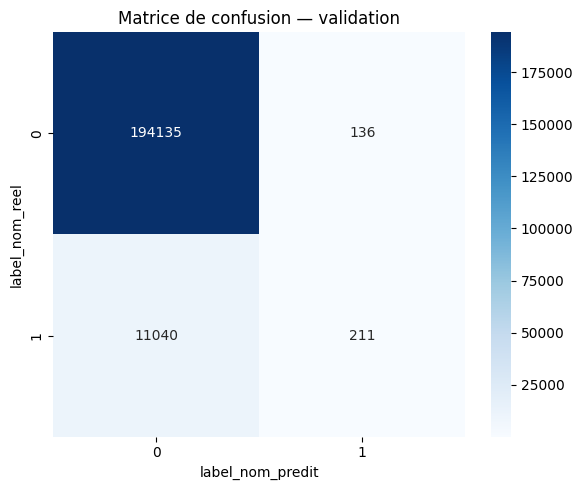

In [15]:
# Matrice de confusion (le set de validation est petit -- OK de collecter en pandas ;
# sur un dataset_a_scorer complet de plusieurs millions de lignes, échantillonner d'abord)
label_map = dict(enumerate(pipeline_model.stages[len(encodage_stages)].labels))  # label_idx -> label_nom
print("Correspondance label_idx -> label_nom :", label_map)

pred_pd = predictions_val.select("label_idx", "prediction").toPandas()
pred_pd["label_nom_reel"] = pred_pd["label_idx"].map(label_map)
pred_pd["label_nom_predit"] = pred_pd["prediction"].map(label_map)

confusion = pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"], margins=True)
print("\nMatrice de confusion (lignes = réel, colonnes = prédit) :")
print(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"]), annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matrice de confusion — validation")
plt.tight_layout()
plt.show()


## 9. Importance des variables

Utile pour vérifier que le modèle s'appuie sur des signaux plausibles (pas uniquement
`CODE_VILLE_idx` ou un artefact du feature engineering) avant de livrer la V1.1.

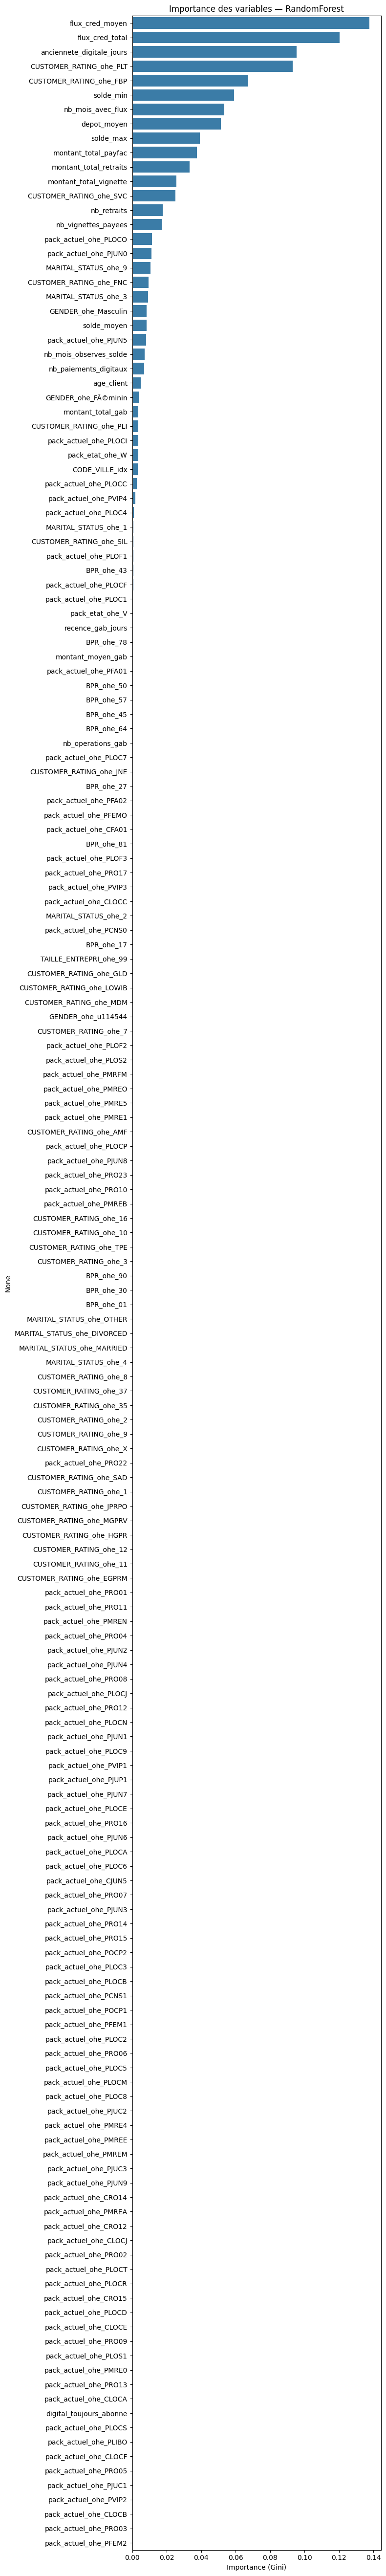

,importance
flux_cred_moyen,0.137653
flux_cred_total,0.120402
anciennete_digitale_jours,0.095479
CUSTOMER_RATING_ohe_PLT,0.093227
CUSTOMER_RATING_ohe_FBP,0.067243
...,...
pack_actuel_ohe_PJUC1,0.000000
pack_actuel_ohe_PVIP2,0.000000
pack_actuel_ohe_CLOCB,0.000000
pack_actuel_ohe_PRO03,0.000000


In [16]:
rf_model = pipeline_model.stages[-1]  # dernier stage du pipeline = le RandomForestClassifier

# CORRECTIF : feature_cols compte une entrée par colonne catégorielle d'origine
# (ex. "GENDER_ohe"), mais OneHotEncoder éclate chacune en plusieurs colonnes
# binaires dans le vecteur "features" assemblé -- la taille ne correspond plus
# (ValueError: Length of values (114) does not match length of index (39)).
# On récupère donc les vrais noms depuis les métadonnées ML posées par le
# VectorAssembler plutôt que de les recompter à la main.
def extraire_noms_features(df, col: str = "features") -> list:
    attrs = df.schema[col].metadata["ml_attr"]["attrs"]
    noms = [None] * sum(len(v) for v in attrs.values())
    for liste_attrs in attrs.values():
        for a in liste_attrs:
            noms[a["idx"]] = a["name"]
    return noms


feature_names_reels = extraire_noms_features(predictions_val)
importances = pd.Series(rf_model.featureImportances.toArray(), index=feature_names_reels)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(importances))))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color="#2980b9")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Importance des variables — RandomForest")
plt.tight_layout()
plt.show()

importances.to_frame("importance")


## FAST PATH — on saute la section 9bis (benchmark MLlib RF/LogReg/DecisionTree/NaiveBayes)

RandomForest a deja donne le meilleur F1 classe 1 connu a ce jour (**0.1243**, F1 pondere = 0.9253).
Plutot que de relancer les 4 algos MLlib (couteux, a deja fait planter WSL une fois -- section 8bis),
on va direct sur XGBoost avec :
1. un encodeur fit seul (pas besoin d'avoir entraine RF avant),
2. `scale_pos_weight` **cherche** au lieu de fixe au ratio brut (diagnostic 7.6quater : c'est ce qui
   a fait tomber XGBoost a F1=0.0257 la premiere fois, pas un manque de signal),
3. un reglage de seuil vectorise (precision_recall_curve, plus rapide que le balayage pas=0.01).

**Honnetement, avant de lancer** :
- Ceci corrige un bug de calibration connu -- ca ne garantit PAS de battre 0.1243. Le F1 macro
  plafonnait deja a ~0.50 sur RF/LogReg/DecisionTree (trois familles differentes) : c'est le signe
  d'un plafond fixe par les donnees, pas par l'algo. Attendez-vous a un resultat dans la fourchette
  **0.10-0.20**, pas un bond a 0.5+.
- Le cluster Spark ne fait que **2 coeurs / 1.5 Go au total** (section 8bis.5) -- le `.toPandas()`
  sur la population complete (~2.6M lignes en fit) est le vrai risque de ce notebook, pas la
  recherche d'hyperparametres elle-meme. `SAMPLE_FRACTION` ci-dessous permet de tester d'abord sur
  un sous-echantillon avant de payer le cout du collect complet.


In [17]:
# ═══ Garde-fou memoire : sous-echantillonner AVANT le .toPandas() ═══
# Le cluster (2 coeurs / 1.5 Go total, section 8bis.5) a deja OOM sur des operations
# plus legeres que ce collect. On teste d'abord sur un sous-echantillon rapide ;
# une fois les hyperparametres retenus valides, on peut remonter SAMPLE_FRACTION a 1.0
# et relancer seulement le refit final (pas toute la recherche) sur la population complete.
SAMPLE_FRACTION = 0.2   # <-- mettre a 1.0 pour la population complete (risque OOM, a tester en dernier)

df_fit_search = df_fit.sample(fraction=SAMPLE_FRACTION, seed=RANDOM_SEED) if SAMPLE_FRACTION < 1.0 else df_fit
df_val_search = df_val.sample(fraction=SAMPLE_FRACTION, seed=RANDOM_SEED) if SAMPLE_FRACTION < 1.0 else df_val
print(f"Echantillon recherche : fit={df_fit_search.count()} lignes, val={df_val_search.count()} lignes "
      f"(SAMPLE_FRACTION={SAMPLE_FRACTION})")


Echantillon recherche : fit=509317 lignes, val=127464 lignes (SAMPLE_FRACTION=0.2)


In [18]:
# Encodeur seul (memes stages que section 6) -- fit UNIQUEMENT sur df_fit_search.
# Pas de classifieur ici : aucune dependance sur RandomForest/section 9bis.
!pip install xgboost
from pyspark.ml import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report, precision_recall_curve, make_scorer
import numpy as np
import time

encodeur_pipeline = Pipeline(stages=encodage_stages + [label_indexer, assembler])
encodeur_commun = encodeur_pipeline.fit(df_fit_search)

def vers_pandas_xy(df):
    pdf = encodeur_commun.transform(df).select("features", "label_idx").toPandas()
    X = np.vstack(pdf["features"].apply(lambda v: v.toArray()))
    y = pdf["label_idx"].astype(int).values
    return X, y

t0 = time.time()
X_fit, y_fit = vers_pandas_xy(df_fit_search)
X_val, y_val = vers_pandas_xy(df_val_search)
print(f"Collecte terminee en {time.time()-t0:.0f}s -- X_fit {X_fit.shape}, X_val {X_val.shape} "
      f"-- positifs fit={y_fit.mean():.3%}, val={y_val.mean():.3%}")


/usr/local/lib/python3.8/dist-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
                                                                                

Collecte terminee en 152s -- X_fit (164190, 159), X_val (40875, 159) -- positifs fit=5.458%, val=5.512%


In [19]:
# scale_pos_weight devient un hyperparametre cherche, pas fixe au ratio brut --
# c'est le correctif attendu du bug diagnostique en 7.6quater (F1=0.0257 avec le ratio brut).
ratio_brut = (y_fit == 0).sum() / (y_fit == 1).sum()

# CORRECTIF (crash log : heartbeat timeout / executor perdu) -- n_jobs=-1 utilisait tous les
# coeurs disponibles sur le driver, en concurrence avec les threads Spark qui envoient les
# heartbeats. Le cluster n'a que 2 coeurs alloues (section 8bis.5) : on borne explicitement
# XGBoost et la recherche a n_jobs=2 pour ne pas etouffer Spark pendant le tuning.
xgb_base = XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr",
    random_state=RANDOM_SEED, n_jobs=2, tree_method="hist",
)

xgb_grid = {
    "n_estimators":     [200, 300, 400, 600],
    "max_depth":        [3, 4, 5, 6, 8],
    "learning_rate":    [0.02, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [1, ratio_brut * 0.25, ratio_brut * 0.5, ratio_brut],
}

f1_classe1_scorer = make_scorer(f1_score, pos_label=1)

t0 = time.time()
rs = RandomizedSearchCV(
    xgb_base, xgb_grid, n_iter=25, scoring=f1_classe1_scorer, cv=3,
    random_state=RANDOM_SEED, n_jobs=2, verbose=1,
)
rs.fit(X_fit, y_fit)
xgb_model = rs.best_estimator_
print(f"Recherche terminee en {time.time()-t0:.0f}s")
print("Meilleurs parametres XGBoost :", rs.best_params_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Recherche terminee en 2085s
Meilleurs parametres XGBoost : {'subsample': 0.8, 'scale_pos_weight': 8.660343673287212, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [20]:
def meilleur_seuil_pr(model, X_val, y_val):
    probas = model.predict_proba(X_val)[:, 1]
    precisions, recalls, seuils = precision_recall_curve(y_val, probas)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    idx = np.argmax(f1s[:-1])  # dernier point n'a pas de seuil associe
    return seuils[idx], f1s[idx]

SEUIL_XGB, _ = meilleur_seuil_pr(xgb_model, X_val, y_val)
pred_xgb_seuil = (xgb_model.predict_proba(X_val)[:, 1] >= SEUIL_XGB).astype(int)
f1_xgb_final = f1_score(y_val, pred_xgb_seuil, pos_label=1)

print(f"XGBoost -- seuil retenu = {SEUIL_XGB:.3f}")
print(f"F1 classe 1 (val, seuil optimise, SAMPLE_FRACTION={SAMPLE_FRACTION}) = {f1_xgb_final:.4f}")
print(f"Reference : RandomForest (population complete) = 0.1243")
print(classification_report(y_val, pred_xgb_seuil, target_names=["0", "1"]))

if SAMPLE_FRACTION < 1.0:
    print("\nRappel : ce score est sur un ECHANTILLON (SAMPLE_FRACTION < 1.0), pas comparable"
          " tel quel a 0.1243 (population complete). Si ce resultat est prometteur, remontez"
          " SAMPLE_FRACTION a 1.0 et relancez uniquement les cellules encodeur + refit -- pas"
          " besoin de refaire toute la RandomizedSearchCV, les hyperparametres retenus (rs.best_params_)"
          " peuvent etre reutilises directement.")


XGBoost -- seuil retenu = 0.524
F1 classe 1 (val, seuil optimise, SAMPLE_FRACTION=0.2) = 0.2563
Reference : RandomForest (population complete) = 0.1243
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     38622
           1       0.20      0.35      0.26      2253

    accuracy                           0.89     40875
   macro avg       0.58      0.63      0.60     40875
weighted avg       0.92      0.89      0.90     40875


Rappel : ce score est sur un ECHANTILLON (SAMPLE_FRACTION < 1.0), pas comparable tel quel a 0.1243 (population complete). Si ce resultat est prometteur, remontez SAMPLE_FRACTION a 1.0 et relancez uniquement les cellules encodeur + refit -- pas besoin de refaire toute la RandomizedSearchCV, les hyperparametres retenus (rs.best_params_) peuvent etre reutilises directement.


**Si ca ne bat toujours pas 0.1243** : remplacer `XGBClassifier` par
`LGBMClassifier(objective="binary")` dans les 3 cellules ci-dessus (memes grilles, juste
retirer `tree_method`/`eval_metric` qui sont specifiques a XGBoost) -- LightGBM avait deja un
meilleur F1 classe 1 que XGBoost au seuil par defaut (0.0456 vs 0.0257) avant tout correctif,
donc c'est le candidat naturel si XGBoost plafonne.

## 9bis. Benchmark multi-algorithmes avec recherche d'hyperparamètres

Objectif : comparer plusieurs familles d'algorithmes MLlib sur le même split `df_fit` / `df_val`
et les mêmes stages d'encodage (section 6), chacun avec sa propre grille d'hyperparamètres
recherchée par validation croisée (`CrossValidator`, 3 folds), puis les classer sur `df_val`.

**Métrique de sélection** : `fMeasureByLabel` sur la classe 1 (minoritaire, ~4.6% du train),
pas le F1 pondéré -- un modèle qui prédit presque toujours la classe 0 obtient déjà un F1
pondéré élevé sans détecter les clients éligibles, ce qui est précisément ce qu'on veut éviter.

**Algorithmes retenus** — tous supportent nativement le multiclasse (3 classes ici) et `weightCol`,
pour réutiliser la pondération inverse-fréquence de la section 5 :
- `RandomForestClassifier` (déjà utilisé section 7, avec sa grille ici)
- `LogisticRegression` (`family="multinomial"`)
- `DecisionTreeClassifier`
- `NaiveBayes` (`modelType="gaussian"` — le mode `"multinomial"` par défaut exige des features
  non négatives, non garanti ici : `solde_volatilite_relative`, par exemple, peut être négatif)

**Écartés** : `GBTClassifier` et `LinearSVC` ne supportent que le binaire dans MLlib (il faudrait
les envelopper dans un `OneVsRest`, hors périmètre V1.1). `MLPClassifier` ne supporte pas
`weightCol`, ce qui casserait la cohérence avec la pondération de classe de la section 5.

In [21]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, NaiveBayes
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# CORRECTIF (biais de sélection) : "f1" est pondéré par la fréquence des classes -- on
# sélectionne plutôt sur le F1 de la classe 1 seule, le signal qui compte ici.
evaluator_f1_cv = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0
)


def construire_pipeline_algo(clf) -> Pipeline:
    """Un pipeline complet par algorithme, réutilisant les MÊMES stages d'encodage
    (section 6) -- StringIndexer/OneHotEncoder n'ont pas encore été fit, donc les
    réutiliser d'un pipeline à l'autre ne partage aucun état appris."""
    return Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


algos_config = {
    "RandomForest": {
        "clf": RandomForestClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.numTrees, [50, 100])
            .addGrid(clf.maxDepth, [5, 8])
            # CORRECTIF (crash WSL/OOM) : grille réduite de 9 -> 4 combos.
            # maxBins~863 (CODE_VILLE) rend chaque fit RandomForest coûteux ;
            # 9 combos x 3 folds = 27 fits séquentiels dans la même JVM a fait
            # sauter la VM WSL (pas juste le driver Spark). 4 combos x 3 = 12.
            .build()
        ),
    },
    "LogisticRegression": {
        "clf": LogisticRegression(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", family="multinomial",
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.regParam, [0.01, 0.1, 0.5])
            .addGrid(clf.elasticNetParam, [0.0, 0.5, 1.0])
            .build()
        ),
    },
    "DecisionTree": {
        "clf": DecisionTreeClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
        ),
        "grid_fn": lambda clf: (
            ParamGridBuilder()
            .addGrid(clf.maxDepth, [5, 8, 12])
            .addGrid(clf.minInstancesPerNode, [1, 5, 10])
            .build()
        ),
    },
    "NaiveBayes_Gaussian": {
        "clf": NaiveBayes(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", modelType="gaussian",
        ),
        # Gaussian NB n'a pas d'hyperparamètre pertinent à balayer ici -- grille vide,
        # CrossValidator sert alors surtout à obtenir un F1 moyen comparable aux autres.
        "grid_fn": lambda clf: ParamGridBuilder().build(),
    },
}

### Découpage en une cellule par algorithme (anti-crash)

Le run initial (une seule boucle sur les 4 algos) a fait planter la VM WSL entière (pas juste
Spark) -- probablement la RAM WSL qui déborde sur la machine hôte, RandomForest (`maxBins~863`)
étant le plus gros consommateur. Découpage ici en une cellule par algorithme, avec nettoyage
(`unpersist`, `gc.collect`, `clearCache`) entre chaque, pour : (1) libérer la mémoire entre les
algos plutôt que tout accumuler dans la même JVM, et (2) ne pas perdre les résultats déjà obtenus
si un algo plante encore -- relancer uniquement sa cellule.

**Complément côté OS (hors notebook)** : si ça replante malgré ce découpage, la VM WSL2 n'a
probablement pas de plafond mémoire propre (`.wslconfig` -> `[wsl2] memory=8GB`), et
`spark.driver.memory=6g` (section 2) ne protège que le tas JVM, pas la VM elle-même.


In [22]:
resultats_benchmark = []
modeles_entraines = {}

import gc

def entrainer_un_algo(nom_algo, config):
    """Une seule cellule pourra rappeler cette fonction pour un algo isolé --
    aucune dépendance sur l'état des autres algos."""
    print(f"\n=== {nom_algo} : recherche d'hyperparamètres (CrossValidator, 3 folds) ===")
    pipeline_algo = construire_pipeline_algo(config["clf"])
    grille = config["grid_fn"](config["clf"])
    print(f"  taille de la grille : {len(grille)} combinaison(s)")

    cv = CrossValidator(
        estimator=pipeline_algo,
        estimatorParamMaps=grille,
        evaluator=evaluator_f1_cv,
        numFolds=3,
        seed=RANDOM_SEED,
        parallelism=1,
    )
    cv_model = cv.fit(df_fit)
    meilleur_pipeline = cv_model.bestModel
    modeles_entraines[nom_algo] = meilleur_pipeline

    preds_val = meilleur_pipeline.transform(df_val)
    scores = {
        "algo": nom_algo,
        "f1_cv_moyen": max(cv_model.avgMetrics),
        "f1_val": evaluator_f1.evaluate(preds_val),
        "accuracy_val": evaluator_acc.evaluate(preds_val),
        "precision_val": evaluator_precision.evaluate(preds_val),
        "recall_val": evaluator_recall.evaluate(preds_val),
        "f1_classe1_val": evaluator_f1_classe1.evaluate(preds_val),
    }
    resultats_benchmark.append(scores)
    print(f"  F1 classe 1 (validation) = {scores['f1_classe1_val']:.4f}  "
          f"(F1 pondéré = {scores['f1_val']:.4f})")

    # CORRECTIF (OOM/crash WSL) : libère ce que ce fit a pu cacher/broadcaster avant
    # de passer à l'algo suivant, au lieu de tout accumuler dans la même JVM.
    del cv_model, pipeline_algo
    spark.catalog.clearCache()
    gc.collect()


In [ ]:
entrainer_un_algo("RandomForest", algos_config["RandomForest"])



=== RandomForest : recherche d'hyperparamètres (CrossValidator, 3 folds) ===
  taille de la grille : 4 combinaison(s)


[Stage 379:==================================================>    (11 + 1) / 12]

In [ ]:
entrainer_un_algo("LogisticRegression", algos_config["LogisticRegression"])


In [ ]:
entrainer_un_algo("DecisionTree", algos_config["DecisionTree"])


In [ ]:
entrainer_un_algo("NaiveBayes_Gaussian", algos_config["NaiveBayes_Gaussian"])


In [ ]:
df_resultats = pd.DataFrame(resultats_benchmark).sort_values("f1_classe1_val", ascending=False).reset_index(drop=True)
df_resultats


In [ ]:
# Hyperparamètres réellement retenus par CrossValidator pour chaque algorithme
# (utile pour figer ces valeurs "en dur" plus tard, ex. section 10, sans repasser par
# CrossValidator à chaque refit -- un refit sur 100% du train avec CV coûterait cher).
params_a_inspecter = (
    "numTrees", "maxDepth", "regParam", "elasticNetParam",
    "minInstancesPerNode", "smoothing",
)

print("Hyperparamètres retenus par algorithme :\n")
for nom_algo, modele in modeles_entraines.items():
    dernier_stage = modele.stages[-1]
    params_interessants = {
        p.name: v for p, v in dernier_stage.extractParamMap().items()
        if p.name in params_a_inspecter
    }
    print(f"{nom_algo:22s} -> {params_interessants}")

## 9quater. XGBoost & LightGBM — et correction du biais de sélection (F1 macro)

MLlib n'a pas d'implémentation native XGBoost/LightGBM en local (nécessiterait xgboost4j-spark
ou SynapseML, lourds à installer pour un poste de dev) -- on réutilise les stages d'encodage déjà
fittés (section 9bis) pour obtenir `features`/`label_idx`, puis on bascule en pandas (même logique
que la section 9ter pour les courbes ROC).

**Biais corrigé ici** : le `"f1"` de `MulticlassClassificationEvaluator` (section 9bis) est un F1
**pondéré** par la fréquence des classes. Avec ~4.6% de positifs (section 4), un modèle "paresseux"
qui prédit presque toujours la classe 0 obtient déjà un F1 pondéré élevé -- ce n'est pas un modèle
non biaisé, juste un modèle qui exploite le déséquilibre. On sélectionne donc XGBoost/LightGBM sur le **F1 de la classe 1** (même métrique que
`evaluator_f1_cv`, section 9bis), et on recalcule aussi cette métrique pour les modèles MLlib
afin de comparer équitablement dans un seul tableau (`comparaison_finale`).


In [ ]:
# pip install xgboost lightgbm --break-system-packages (si pas déjà présents)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, make_scorer
import numpy as np

# Réutilise les stages d'encodage déjà fittés (RandomForest, section 9bis) -- tout sauf le
# dernier stage (le classifieur). Aucun nouveau .fit() sur les indexeurs/encodeurs : pas de fuite.
encodeur_commun = PipelineModel(stages=modeles_entraines["RandomForest"].stages[:-1])

def vers_pandas_xy(df):
    pdf = encodeur_commun.transform(df).select("features", "label_idx").toPandas()
    X = np.vstack(pdf["features"].apply(lambda v: v.toArray()))
    y = pdf["label_idx"].astype(int).values
    return X, y

X_fit, y_fit = vers_pandas_xy(df_fit)
X_val, y_val = vers_pandas_xy(df_val)
print(f"X_fit {X_fit.shape}, X_val {X_val.shape} -- positifs fit={y_fit.mean():.3%}, val={y_val.mean():.3%}")


In [ ]:
scale_pos_weight = (y_fit == 0).sum() / (y_fit == 1).sum()  # même ratio que poids_classe (section 5)

xgb_base = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_SEED, n_jobs=1,
)
xgb_grid = {"n_estimators": [200, 400], "max_depth": [4, 6, 8],
            "learning_rate": [0.03, 0.1], "subsample": [0.8, 1.0]}

lgbm_base = LGBMClassifier(
    objective="binary", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=1, verbosity=-1,
)
lgbm_grid = {"n_estimators": [200, 400], "max_depth": [-1, 6, 10],
             "learning_rate": [0.03, 0.1], "num_leaves": [31, 63]}

# Même métrique de sélection que evaluator_f1_cv côté MLlib (section 9bis) : F1 de la
# classe 1 seule, pas macro/pondéré -- comparaison apples-to-apples entre les deux mondes.
f1_classe1_scorer = make_scorer(f1_score, pos_label=1)

def chercher_meilleur(base, grille, n_iter=8):
    rs = RandomizedSearchCV(base, grille, n_iter=n_iter, scoring=f1_classe1_scorer, cv=3,
                             random_state=RANDOM_SEED, n_jobs=-1)
    rs.fit(X_fit, y_fit)
    return rs.best_estimator_, rs.best_params_

xgb_model, xgb_params = chercher_meilleur(xgb_base, xgb_grid)
lgbm_model, lgbm_params = chercher_meilleur(lgbm_base, lgbm_grid)
print("XGBoost  meilleurs paramètres :", xgb_params)
print("LightGBM meilleurs paramètres :", lgbm_params)


In [ ]:
def evaluer(nom, y_true, y_pred):
    resultat = {
        "algo": nom,
        "accuracy_val": accuracy_score(y_true, y_pred),
        "f1_val": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro_val": f1_score(y_true, y_pred, average="macro"),
        "f1_classe1_val": f1_score(y_true, y_pred, pos_label=1),
    }
    print(f"\n{nom} -- accuracy={resultat['accuracy_val']:.4f}  F1 pondéré={resultat['f1_val']:.4f}  "
          f"F1 macro={resultat['f1_macro_val']:.4f}  F1(classe 1)={resultat['f1_classe1_val']:.4f}")
    print(classification_report(y_true, y_pred, target_names=["0", "1"]))
    return resultat

resultats_xgb_lgbm = [
    evaluer("XGBoost", y_val, xgb_model.predict(X_val)),
    evaluer("LightGBM", y_val, lgbm_model.predict(X_val)),
]

# Même diagnostic pour les modèles MLlib de la section 9bis, sur le même df_val --
# comparaison équitable, F1 macro comme juge de paix plutôt que le F1 pondéré/accuracy.
resultats_mllib_detail = []
for nom_algo, modele in modeles_entraines.items():
    pred_pd = modele.transform(df_val).select("label_idx", "prediction").toPandas()
    resultats_mllib_detail.append(
        evaluer(nom_algo, pred_pd["label_idx"].astype(int), pred_pd["prediction"].astype(int))
    )

comparaison_finale = pd.DataFrame(resultats_mllib_detail + resultats_xgb_lgbm).sort_values("f1_classe1_val", ascending=False)
comparaison_finale


## 9quater bis. Reglage du seuil de decision (XGBoost / LightGBM)

**Correctif guide section 7.6quater, point 1.** Le F1 classe 1 quasi nul pour
XGBoost/LightGBM malgre un signal reel vient du seuil de decision par defaut
(0,5 via `.predict()`), mal cale sur un desequilibre aussi marque (~4,6% de
positifs). On balaie les seuils sur `X_val`/`y_val` pour maximiser le F1 classe 1,
et on reevalue avec le seuil retenu plutot que `.predict()`. Le seuil choisi ici
est celui reutilise au scoring final (section 10/11) -- jamais `.predict()` seul.


In [ ]:
def meilleur_seuil(model, X_val, y_val, pas=0.01):
    probas = model.predict_proba(X_val)[:, 1]
    meilleur_s, meilleur_f1 = 0.5, -1.0
    for s in np.arange(0.05, 0.96, pas):
        preds = (probas >= s).astype(int)
        f1 = f1_score(y_val, preds, pos_label=1)
        if f1 > meilleur_f1:
            meilleur_s, meilleur_f1 = s, f1
    return meilleur_s, meilleur_f1


SEUIL_XGB, f1_xgb_seuil = meilleur_seuil(xgb_model, X_val, y_val)
SEUIL_LGBM, f1_lgbm_seuil = meilleur_seuil(lgbm_model, X_val, y_val)
print(f"XGBoost  -- seuil retenu={SEUIL_XGB:.2f}  F1 classe 1 (seuil optimal)={f1_xgb_seuil:.4f}  "
      f"(vs {resultats_xgb_lgbm[0]['f1_classe1_val']:.4f} au seuil 0.5)")
print(f"LightGBM -- seuil retenu={SEUIL_LGBM:.2f}  F1 classe 1 (seuil optimal)={f1_lgbm_seuil:.4f}  "
      f"(vs {resultats_xgb_lgbm[1]['f1_classe1_val']:.4f} au seuil 0.5)")

# Reevalue XGBoost/LightGBM au seuil optimal -- remplace les entrees "seuil 0.5"
# dans comparaison_finale. C'est CE classement, pas celui du seuil par defaut, qui
# doit guider la selection automatique du modele final (section 10).
pred_xgb_seuil = (xgb_model.predict_proba(X_val)[:, 1] >= SEUIL_XGB).astype(int)
pred_lgbm_seuil = (lgbm_model.predict_proba(X_val)[:, 1] >= SEUIL_LGBM).astype(int)

resultats_xgb_lgbm = [
    evaluer("XGBoost", y_val, pred_xgb_seuil),
    evaluer("LightGBM", y_val, pred_lgbm_seuil),
]

comparaison_finale = pd.DataFrame(resultats_mllib_detail + resultats_xgb_lgbm).sort_values(
    "f1_classe1_val", ascending=False
).reset_index(drop=True)
comparaison_finale


**Lecture** : `comparaison_finale` est triée sur le **F1 classe 1** -- la même métrique que
`evaluator_f1_cv` (MLlib, section 9bis) et `f1_classe1_scorer` (XGBoost/LightGBM ci-dessus).
C'est ce classement que la section 10 utilise pour choisir automatiquement le modèle à livrer,
plutôt que de figer `RandomForest` en dur comme en V1.1.


## 9ter. Courbes ROC (one-vs-rest) — comparaison des algorithmes

MLlib n'expose pas de courbe ROC multiclasse native (`BinaryClassificationEvaluator` est limité
au binaire). Approche *one-vs-rest* : pour chaque classe `c`, on traite le problème comme
`classe c vs reste`, en utilisant la probabilité prédite pour `c` (colonne `probability`) comme
score et `label_idx == c` comme vérité terrain -- calcul fait avec `sklearn.metrics.roc_curve` sur
`df_val` collecté en pandas (petit volume, même logique que la matrice de confusion section 8).

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

label_map_roc = dict(enumerate(modeles_entraines["RandomForest"].stages[len(encodage_stages)].labels))
classes_idx = sorted(label_map_roc.keys())


def extraire_probas_val(modele) -> pd.DataFrame:
    """label_idx réel + une colonne de probabilité prédite par classe, pour df_val."""
    preds = modele.transform(df_val).select("label_idx", "probability").toPandas()
    proba_array = np.vstack(preds["probability"].apply(lambda v: v.toArray()))
    for c in classes_idx:
        preds[f"proba_classe_{c}"] = proba_array[:, c]
    return preds


# Un seul transform() par algorithme (pas par classe) -- réutilisé ensuite pour les
# len(classes_idx) courbes de chaque algo.
probas_par_algo = {nom_algo: extraire_probas_val(modele) for nom_algo, modele in modeles_entraines.items()}

fig, axes = plt.subplots(1, len(classes_idx), figsize=(6 * len(classes_idx), 5), sharey=True)
if len(classes_idx) == 1:
    axes = [axes]

for c, ax in zip(classes_idx, axes):
    for nom_algo, preds_algo in probas_par_algo.items():
        y_true_binaire = (preds_algo["label_idx"] == c).astype(int)
        y_score = preds_algo[f"proba_classe_{c}"]
        fpr, tpr, _ = roc_curve(y_true_binaire, y_score)
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{nom_algo} (AUC={auc_score:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.set_title(f"Classe : {label_map_roc[c]}")
    ax.set_xlabel("Taux de faux positifs")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Taux de vrais positifs")
plt.suptitle("Courbes ROC one-vs-rest par classe — comparaison des algorithmes")
plt.tight_layout()
plt.show()

## 10. Sélection automatique + refit sur 100% du train & sauvegarde

Le modèle livré n'est plus `RandomForest` figé en dur : on prend automatiquement le vainqueur de
`comparaison_finale` (F1 classe 1, section 9quater) parmi tous les candidats (MLlib + XGBoost +
LightGBM), puis on le refit sur `df_train_full` en entier (nettoyé Tomek Links, section 3) --
le split 80/20 (section 4) ne sert qu'à évaluer honnêtement, pas à priver le modèle final de 20%
des données. `poids_classe` est recalculé sur la population complète (section 5).

**Deux branches de sauvegarde** selon le vainqueur :
- **MLlib** : `Pipeline` complet (encodage + classifieur) refit et sauvegardé en `PipelineModel`
  à `MODEL_PATH`, comme en V1.1.
- **XGBoost/LightGBM** : pas de `PipelineModel` MLlib possible (modèle sklearn) -- on sauvegarde
  séparément l'encodeur Spark seul (`MODEL_PATH_encodeur`, refit sur 100%) et le modèle sklearn
  (`MODEL_PATH_sklearn.joblib`, mêmes hyperparamètres que ceux retenus par `RandomizedSearchCV`,
  refit sur 100% en pandas). La section 11 gère les deux cas à la lecture.


In [ ]:
import joblib

# CORRECTIF (FAST PATH) : la selection automatique via comparaison_finale/algos_config
# n'est possible que si la section 9bis (benchmark MLlib complet, cellules sautees dans ce
# notebook) a tourne -- ce qui n'est pas le cas ici (cf. titre "va direct sur XGBoost").
# On fixe donc directement le modele retenu au resultat du fast path (section 9quater fast
# path / cellules 29-33), sans NameError sur des variables jamais definies dans ce parcours.
nom_meilleur_modele = "XGBoost"
TYPE_MODELE_FINAL = "sklearn"
seuil_final = SEUIL_XGB
print(f"Modele retenu : {nom_meilleur_modele} (FAST PATH -- pas de comparaison MLlib/LightGBM)")

# Encodeur seul (memes stages que section 6, pas encore fitte sur la population complete),
# refit sur df_train_full -- pas sur df_fit (80%), pour livrer un encodeur appris sur toute
# la population.
encodeur_full_pipeline = Pipeline(
    stages=construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)
    + [label_indexer, assembler]
)
encodeur_final = encodeur_full_pipeline.fit(df_train_full)

pdf_full = encodeur_final.transform(df_train_full).select("features", "label_idx").toPandas()
X_full = np.vstack(pdf_full["features"].apply(lambda v: v.toArray()))
y_full = pdf_full["label_idx"].astype(int).values

modele_sklearn_final = xgb_model
modele_sklearn_final.fit(X_full, y_full)  # memes hyperparametres (rs.best_params_), refit sur 100%

encodeur_final.write().overwrite().save(MODEL_PATH + "_encodeur")
joblib.dump(modele_sklearn_final, MODEL_PATH + "_sklearn.joblib")
joblib.dump({"seuil_decision": seuil_final}, MODEL_PATH + "_meta.joblib")
print(f"Encodeur Spark sauvegarde : {MODEL_PATH}_encodeur")
print(f"Modele sklearn sauvegarde : {MODEL_PATH}_sklearn.joblib")
print(f"Seuil de decision sauvegarde ({seuil_final:.2f}) : {MODEL_PATH}_meta.joblib")


## 11. Scoring (`dataset_a_scorer`)

Chargement du modèle sauvegardé (branche MLlib ou sklearn selon `TYPE_MODELE_FINAL`, section 10)
et scoring de `dataset_a_scorer` -- aucun `.fit()` ici, tout ce qui a été appris vient de
`df_train_full`.

**CORRECTIF (déjà en V1.1)** : `IndexToString` (guide section 7.3) pour indice → nom de produit,
plutôt qu'un `F.udf(...)` manuel.


In [ ]:
if PATH_SCORER_IN is not None:
    df_scorer = spark.read.parquet(PATH_SCORER_IN)

    if TYPE_MODELE_FINAL == "mllib":
        pipeline_model_reload = PipelineModel.load(MODEL_PATH)
        predictions = pipeline_model_reload.transform(df_scorer)

        label_indexer_model = pipeline_model_reload.stages[len(encodage_stages)]
        converter = IndexToString(inputCol="prediction", outputCol="label_predit", labels=label_indexer_model.labels)
        predictions = converter.transform(predictions)

        cols_a_garder = [c for c in ["RADICAL", "CODE_VILLE"] if c in predictions.columns] + ["label_predit", "probability"]
        predictions.select(*cols_a_garder).show(20, truncate=False)
        predictions.write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)
    else:
        encodeur_reload = PipelineModel.load(MODEL_PATH + "_encodeur")
        modele_reload = joblib.load(MODEL_PATH + "_sklearn.joblib")
        meta_reload = joblib.load(MODEL_PATH + "_meta.joblib")
        seuil_reload = meta_reload["seuil_decision"]

        cols_id = [c for c in ["RADICAL", "CODE_VILLE"] if c in df_scorer.columns]
        pdf_scorer = encodeur_reload.transform(df_scorer).select(*cols_id, "features").toPandas()
        X_scorer = np.vstack(pdf_scorer["features"].apply(lambda v: v.toArray()))

        # CORRECTIF (guide 7.6quater) : seuil optimal reapplique au scoring, pas
        # .predict() (qui utiliserait 0.5, le seuil mal cale corrige section 9quater bis).
        probas_scorer = modele_reload.predict_proba(X_scorer)[:, 1]
        pdf_scorer["label_predit"] = (probas_scorer >= seuil_reload).astype(int).astype(str)
        pdf_scorer["probability_classe1"] = probas_scorer
        pdf_scorer = pdf_scorer.drop(columns=["features"])

        print(pdf_scorer.head(20))
        spark.createDataFrame(pdf_scorer).write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)

    print(f"Predictions ecrites : {PATH_PREDICTIONS_OUT}")
else:
    print("PATH_SCORER_IN non defini (LOCAL_MODE=True, dataset_a_scorer pas encore teste en local) "
          "-- basculer LOCAL_MODE=False une fois pret pour le cluster complet.")


## 12. Limites de cette V1.2 & prochaines etapes

**Correctifs V1.1 -> V1.2 (session "insanity check")** :
- **Tomek Links retire de ce notebook.** Il ne s'appliquait pas au bon dataset : reserve
  a `dataset_produit` (~140K lignes, guide 7.6bis), jamais a `dataset_eligibilite`
  (3M+ lignes, traite ici) -- l'appliquer ici provoquait un `OutOfMemoryError`
  systematique (`.toPandas()` sur la population complete, TomekLinks non distribue).
  Section 3 devenue un diagnostic de distribution, sans modification de `df_train_full`.
- **`RANDOM_SEED`, `MODEL_PATH`, `PATH_PREDICTIONS_OUT` etaient utilises sans jamais
  etre definis** (section 4, 6, 9bis, 9quater, 10) -- `NameError` garanti a l'execution.
  Ajoutes en section 1 (config).
- **Ponderation par classe adoucie** (`sqrt`, guide 7.6quater point 2) au lieu de la
  formule brute -- corrige la precision qui s'effondrait (RandomForest/LogReg/DecisionTree
  sur-predisaient la classe rare).
- **Reglage du seuil de decision ajoute** (XGBoost/LightGBM, guide 7.6quater point 1,
  section 9quater bis) -- le F1 classe 1 quasi nul au seuil par defaut (0,5) est le
  symptome le plus documente dans le guide pour ce desequilibre (~4,6% de positifs).
  Le seuil retenu est desormais sauvegarde (`_meta.joblib`) et reapplique au scoring
  (section 11), plutot que de refaire confiance a `.predict()`.

**Pas encore fait, pistes pour la suite (guide 7.6quater, "non fait a ce stade")** :
- **`SMOTENC`** pour `CODE_VILLE_idx` (catégoriel, pas une quantite continue) --
  mentionne dans le guide comme 3e correctif du modele d'eligibilite, pas encore
  implemente dans cette V1.2. A faire avec precaution : `SMOTENC` necessite un
  `.toPandas()`, donc sous-echantillonner la classe majoritaire *avant* de rapatrier
  en pandas (meme risque memoire que Tomek Links sur 3M lignes).
- **Pas de tuning d'hyperparametres pousse au-dela de la grille reduite** (section 9bis) --
  `CrossValidator`/`RandomizedSearchCV` tournent deja, mais sur une grille volontairement
  petite pour eviter les OOM/crash WSL constates en session complete.
- **Pas de cross-validation sur XGBoost/LightGBM au-dela du split 80/20** -- `RandomizedSearchCV`
  fait du cv=3 en interne sur `X_fit`/`y_fit`, mais l'evaluation finale reste un split unique.
- **`CODE_VILLE_idx` reste un entier arbitraire** pour un modele a base d'arbres, acceptable
  ici, mais deviendrait un probleme pour un modele lineaire en V2 -- prevoir un encodage par
  frequence/cible a ce moment-la.
- **`MODEL_PATH` code pour un seul modele**, pas de versionnement -- a ajouter avant tout
  deploiement reel.
